# Static fluids and the Dahlen closure

In the Love-number tutorial we used a *solid* sphere and noted, in passing, that a
**fluid** sphere would misbehave. This notebook is that footnote, worked out: the
fluid sphere gives the right surface numbers ($h=5/2,\ k=3/2$) but **garbage
interior profiles** — and `dahlenize` is the fix. Same one-layer sphere, now fluid.

It reuses the assembly pipeline from notebook 1, so we keep that part short.


In [1]:
using Pkg; Pkg.activate(@__DIR__)
using Melinoe, ApproxFun, PyPlot, Printf, LinearAlgebra

m = Melinoe.Models.Kelvin()          # incompressible FLUID sphere (μ̃ = 0): ρ = 1, g(r) = r
ℓ = 2; rr = range(0, 1, length = 200)

  Activating project at `~/code/ge-julia/examples`


0.0:0.005025125628140704:1.0

### Why the middle field is $P$, not $V$

A fluid has $\mu=0$: no shear, so the tangential-*displacement* equation degenerates.
The **P-formulation** swaps $V$ for the Lagrangian pressure $P \equiv -\kappa\,\nabla\!\cdot\!\mathbf{u}$,
and recovers $V$ afterward from $V = \tfrac{r}{\ell(\ell+1)}(U' + 2U/r + P/\kappa)$. So a
fluid layer solves for $(U, P, \delta\phi)$ — that is the $P$ plotted below, and it is why
the gauge freedom lands on $U$ and $P$, not $V$. (This sphere is incompressible,
$\kappa=\infty$; the $P/\kappa$ terms simply drop — `is_incompressible` handles it.)

## 1 · The solve looks fine — until you plot it

Run the pipeline. The surface Love numbers are **exact**:


h = 2.500000   k = 1.500000   (exact 5/2, 3/2)


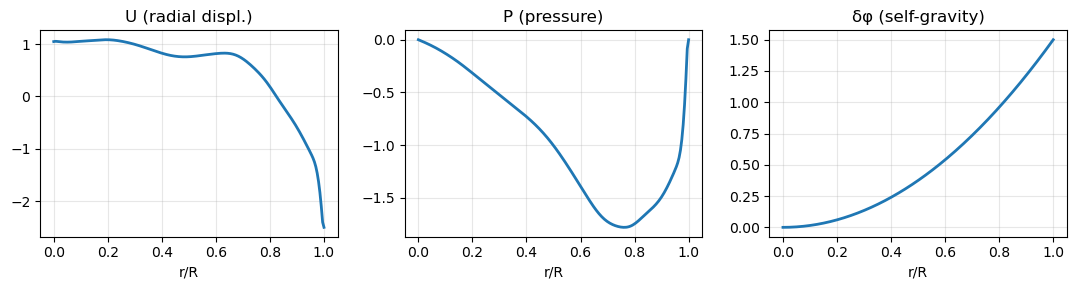

In [2]:
# notebook 1 built the matrix by hand; here we let the library assemble it, but the
# solve is the same good old  x = A \ f.
A, _, ops, ns, jr = assemble_planet(m.layers, ℓ)
f = potential_forcing(ops, ns; ℓ, jrhs = jr)       # tidal body force
x = A \ f                                          # ← the solve
N = ns[1]; S = ops[1].S
U = Fun(S, x[1:N]);  P = Fun(S, x[N+1:2N]);  δφ = Fun(S, x[2N+1:3N])

ln = love_numbers(m)
@printf("h = %.6f   k = %.6f   (exact 5/2, 3/2)\n", -ln.h, ln.k)

fig, ax = subplots(1, 3, figsize = (11, 3.0))
for (a, y, t) in zip(ax, (U, P, δφ), ("U (radial displ.)", "P (pressure)", "δφ (self-gravity)"))
    a.plot(rr, [y(r) for r in rr], lw = 2); a.set_xlabel("r/R"); a.set_title(t); a.grid(alpha = 0.3)
end
tight_layout(); gcf()

`δφ` is smooth, but **`U` and `P` wobble** — they are not physical. Yet $h$ and $k$
came out exactly right. How can the surface values be correct if the interior field
is junk?


## 2 · The static-fluid gauge freedom

In a **static** ($\omega=0$), **inviscid** ($\mu=0$) fluid the momentum equation
collapses to

$$\delta p = -\rho_0(\delta\phi + \Phi_T),$$

and the displacement has **dropped out of the interior**. With uniform density the
stratification $N^2 = 0$, so an internal divergence-free rearrangement of fluid
parcels costs *zero energy* — statics can neither see it nor forbid it. The interior
$U$ is therefore determined only up to that null space, and the solver returns an
arbitrary member of it: the wobble.

What *is* pinned: $\delta\phi$ (a rearrangement moves no mass, so it is untouched)
and, through the boundary conditions, the surface $h$ and $k$. Hence exact Love
numbers riding on a meaningless interior.


In [3]:
# the wobble is real: U's surface slope is huge, so the tangential number
# reconstructed from it is junk — and it moves wildly if you change n.
l_raw = (U'(1.0) + 2U(1.0)) / (ℓ*(ℓ+1))      # r/(ℓ(ℓ+1))·(U′ + 2U/r);  κ = ∞ here
@printf("U'(1)    = %9.3f   (a smooth field would be O(1))\n", U'(1.0))
@printf("l (raw)  = %9.3f   ← gauge junk: rerun with another n and it changes sign\n", l_raw)
@printf("ln.l     = %9s   ← so love_numbers declines to report it\n", string(ln.l))
@printf("δφ(1)=k  = %9.3f   h = %.3f   (both physical)\n", ln.k, -ln.h)

# For the record, "the" fluid l₂ depends on which limit you take, and neither
# mechanism is present here (static AND inviscid):
#   solid, μ̃ → 0        → 3/4   (pinned by shear traction)
#   fluid, ω² → 0⁺      → 5/4   (pinned by inertia)


## 3 · The Dahlen closure — stop solving for the displacement

The cure (Dahlen 1974): in a static fluid the density perturbation is set by the
**potential**, not the displacement,

$$\rho_1 = \rho_0'\,\frac{\delta\phi + \Phi_T}{g_0}.$$

Substitute into Poisson and the fluid **closes on $\delta\phi$ alone** (here
$\rho_0'=0$, so it is simply $\nabla^2\delta\phi=0$). The displacement demotes to an
algebraic **slave** — *the fluid rides the equipotential*:

$$U = -\frac{\delta\phi + \Phi_T}{g_0}.$$

That single choice fixes the gauge. `dahlenize(model)` flips every fluid layer to
this closure.


dahlenized:  h = 2.500000   k = 1.500000   (unchanged)


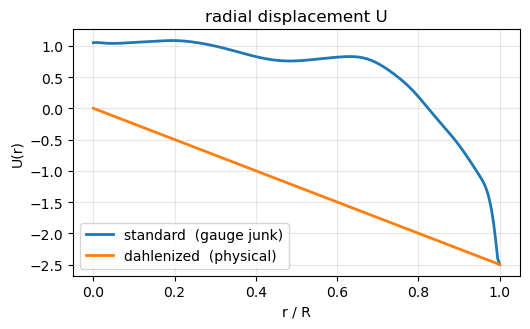

In [4]:
md = dahlenize(m)                                   # same model, fluid closure flipped
Ad, _, opsd, nsd, jrd = assemble_planet(md.layers, ℓ)
xd = Ad \ potential_forcing(opsd, nsd; ℓ, jrhs = jrd)   # the same  x = A \ f
Sd = opsd[1].S
Ud = Fun(Sd, xd[1:N]);  Pd = Fun(Sd, xd[N+1:2N]);  δφd = Fun(Sd, xd[2N+1:3N])

lnd = love_numbers(md)
@printf("dahlenized:  h = %.6f   k = %.6f   (unchanged)\n", -lnd.h, lnd.k)

fig, ax = subplots(figsize = (5.4, 3.4))
ax.plot(rr, [U(r)  for r in rr], lw = 2, label = "standard  (gauge junk)")
ax.plot(rr, [Ud(r) for r in rr], lw = 2, label = "dahlenized  (physical)")
ax.set_xlabel("r / R"); ax.set_ylabel("U(r)"); ax.set_title("radial displacement U")
ax.legend(); ax.grid(alpha = 0.3); tight_layout(); gcf()

Same $h,k$; the interior is now the clean $U = -\tfrac52 r$. The wobble is gone
because the null space is gone — $U$ is no longer a free unknown.


## 4 · The riding relation, checked

The dahlenized $U$ is not *solved for* — it is the algebraic slave $-(\delta\phi+\Phi_T)/g_0$.
Verify it holds pointwise:


In [5]:
g = md.layers[1].g₀
res = maximum(abs(Ud(r) + (δφd(r) + r^ℓ)/g(r)) for r in range(0.05, 1, length = 100))
@printf("max |U + (δφ + Φ)/g| = %.1e   (riding relation holds)\n", res)

max |U + (δφ + Φ)/g| = 1.5e-10   (riding relation holds)


## 5 · What changed — in the matrix

`dahlenize` keeps the $3N\times3N$ layout and sparsity — it rewrites **equations, not
structure**. Difference the two matrices: only the **$U$ (momentum) rows** light up; the
$P$ and $\delta\phi$ rows, boundary rows included (red: $P=0$ and gravity), are
byte-identical. The closure swaps the $U$ block's *differential* momentum operator for the
pure $r^2 g_0$ multiplication that **is** the slave $U = -(\delta\phi+\Phi)/g_0$ — that one
row-block swap is the whole closure. (Wall-free sphere ⇒ no boundary-condition change; here
$\rho_0'=0$ also makes $\delta\phi$ Laplace in both.)

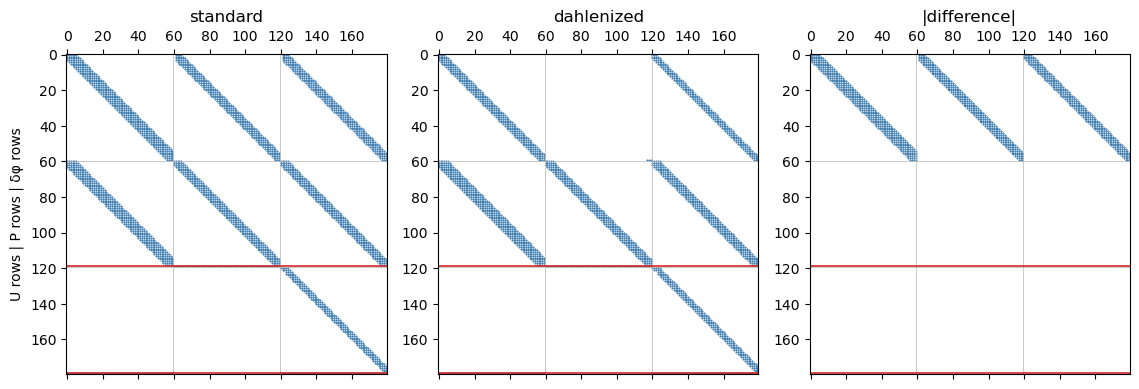

In [6]:
# A and Ad are the very matrices we just solved
fig, ax = subplots(1, 3, figsize = (11.5, 3.8))
for (M, a, t) in zip((A, Ad, abs.(A .- Ad)), ax, ("standard", "dahlenized", "|difference|"))
    a.spy(M, markersize = 0.5, color = "steelblue")
    for b in (N, 2N); a.axvline(b-0.5, color="0.7", lw=0.5); a.axhline(b-0.5, color="0.7", lw=0.5); end
    for r in (2N, 3N); a.axhline(r-1, color="C3", lw=1.2); end   # boundary rows (P=0, gravity)
    a.set_title(t)
end
ax[1].set_ylabel("U rows | P rows | δφ rows")
tight_layout(); gcf()

### The boundary change needs a wall

So where *does* a boundary condition change? At a **fluid–solid interface**. Add one — a
fluid core under a solid mantle. There the standard junction reads the fluid's slave
pressure $P$; the Dahlen junction instead writes the load directly,
$-P = \rho\,(g_0 U + \delta\phi + \Phi)$, which puts the applied potential $\Phi$ *on the
interface* and moves it to the right-hand side — the **interface forcing** `jrhs`. It is
the one boundary forcing in the whole framework, and it appears only when dahlenized.


In [7]:
m2  = build_model("fluid core + solid mantle", [0.0..0.5, 0.5..1.0], [[1.5], [1.0]],
                  [r->2.0, r->3.0], [r->0.0, r->1.5], [24, 24]; R_SI = 6371e3, ρ̄_SI = 5000.0)
_, _, _, _, js = assemble_planet(m2.layers, ℓ)
_, _, _, _, jd = assemble_planet(dahlenize(m2).layers, ℓ)
@printf("interface forcing jrhs:  standard %d   dahlenized %d  (at r = %.2f)\n",
        length(js), length(jd), jd[1].r0)
l2, l2d = love_numbers(m2.layers, ℓ), love_numbers(dahlenize(m2).layers, ℓ)
@printf("Love numbers unchanged by the closure:  h  %.4f == %.4f\n", -l2.h, -l2d.h)


interface forcing jrhs:  standard 0   dahlenized 1  (at r = 0.50)
Love numbers unchanged by the closure:  h  0.3131 == 0.3131


## 6 · When you need it

The cost: fluid inertia is dropped, so this is **static solves only** — `free_modes`
on a dahlenized model is meaningless. For a **stratified** fluid ($\rho_0'\neq0$) or one
bounded by solid walls, `dahlenize` *also* rewrites the $\delta\phi$ row (the closed core
equation) and adds an interface forcing — invisible here because this sphere is uniform
and wall-free. At **diurnal** frequency the $\rho_0\omega^2$ term restores the displacement,
so no dahlenize is needed.
